In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
import pickle


In [2]:
#Load the dataset
data = pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
## Preprocessing the data
## Drop irrelevant columns
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
data


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
## Encode categorical variables
label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])
data


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [5]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [6]:
##One hot encode geography column
from sklearn.preprocessing import OneHotEncoder
onehot_encoder_geo = OneHotEncoder()
geo_encoder = onehot_encoder_geo.fit_transform(data[['Geography']])
geo_encoder

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10000 stored elements and shape (10000, 3)>

In [7]:
onehot_encoder_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [8]:
geo_encoded_df = pd.DataFrame(geo_encoder.toarray(), columns=onehot_encoder_geo.get_feature_names_out(['Geography']))

In [9]:
geo_encoded_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [10]:
## combine one hot encoded geography columns with the original dataset
data = pd.concat([data.drop('Geography',axis = 1), geo_encoded_df], axis=1)
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [11]:
## Save encoders and scaler
with open('label_encoder_gender.pkl', 'wb') as file:
    pickle.dump(label_encoder_gender, file)

with open('onehot_encoder_geo.pkl', 'wb') as file:
    pickle.dump(onehot_encoder_geo, file)



In [12]:
## Divide dataset into independent and dependent variables
X = data.drop('Exited', axis=1)
y = data['Exited']

## Split into training and temporary sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## Split temporary set into validation and testing sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2/3,
    random_state=42,
    stratify=y_temp
)

## Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [13]:
X_train

array([[-0.57558225,  0.90036493, -1.79667873, ...,  1.00314781,
        -0.57823004, -0.57888987],
       [ 0.39818245, -1.11066076,  2.26982524, ..., -0.99686207,
        -0.57823004,  1.72744428],
       [ 1.69308232,  0.90036493, -0.75641027, ...,  1.00314781,
        -0.57823004, -0.57888987],
       ...,
       [ 0.17028007, -1.11066076, -0.18899111, ...,  1.00314781,
        -0.57823004, -0.57888987],
       [ 0.37746405,  0.90036493, -0.37813083, ..., -0.99686207,
        -0.57823004,  1.72744428],
       [ 1.56877193,  0.90036493,  1.13498693, ..., -0.99686207,
        -0.57823004,  1.72744428]])

In [14]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [15]:
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


### ANN Implementation

In [16]:
import tensorflow as tf


2026-09-21 20:22:44.510233: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [17]:
tf.__version__

'2.15.0'

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import datetime

In [19]:
X_train.shape[1]

12

In [20]:
## Build the ANN model
model = Sequential(
    [Dense(64,activation = 'relu',input_shape = (X_train.shape[1],)),##HL1
    Dense(32,activation = 'relu'),##HL2
    Dense(1,activation = 'sigmoid')##Output layer
]
)



In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                832       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2945 (11.50 KB)
Trainable params: 2945 (11.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.001)
loss = tensorflow.keras.losses.BinaryCrossentropy()
loss

In [23]:
## Compile the model
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
from tensorflow.keras.callbacks import TensorBoard ,EarlyStopping

In [25]:
## Set up tensorboard
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorflow_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [26]:
## Set up EarlyStopping - Used to stop training when the model stops improving on the validation set
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[tensorflow_callback, early_stopping_callback]
)

Epoch 1/100
219/219 [==============================] - 3s 6ms/step - loss: 0.4571 - accuracy: 0.8043 - val_loss: 0.4065 - val_accuracy: 0.8210
Epoch 2/100
219/219 [==============================] - 1s 4ms/step - loss: 0.3937 - accuracy: 0.8384 - val_loss: 0.3737 - val_accuracy: 0.8370
Epoch 3/100
219/219 [==============================] - 1s 3ms/step - loss: 0.3639 - accuracy: 0.8501 - val_loss: 0.3546 - val_accuracy: 0.8370
Epoch 4/100
219/219 [==============================] - 1s 3ms/step - loss: 0.3523 - accuracy: 0.8533 - val_loss: 0.3532 - val_accuracy: 0.8440
Epoch 5/100
219/219 [==============================] - 1s 4ms/step - loss: 0.3457 - accuracy: 0.8584 - val_loss: 0.3485 - val_accuracy: 0.8470
Epoch 6/100
219/219 [==============================] - 0s 2ms/step - loss: 0.3417 - accuracy: 0.8567 - val_loss: 0.3503 - val_accuracy: 0.8440
Epoch 7/100
219/219 [==============================] - 1s 4ms/step - loss: 0.3389 - accuracy: 0.8581 - val_loss: 0.3542 - val_accuracy: 0.8360

In [28]:
model.save('churn_model.keras')

In [29]:
## Evaluate the model on the test set

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 [==============================] - 0s 1ms/step - loss: 0.3249 - accuracy: 0.8770
Test Loss: 0.32486122846603394
Test Accuracy: 0.8769999742507935


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

## Predictions on test set
y_pred_probability = model.predict(X_test)
y_pred = (y_pred_probability > 0.5).astype(int)

## Classification Report
print(classification_report(y_test, y_pred))

63/63 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      1593
           1       0.79      0.54      0.64       407

    accuracy                           0.88      2000
   macro avg       0.84      0.75      0.78      2000
weighted avg       0.87      0.88      0.87      2000



In [36]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1535   58]
 [ 188  219]]


In [37]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_probability)
print("ROC-AUC:", auc)

ROC-AUC: 0.8680005120683087


Matplotlib is building the font cache; this may take a moment.


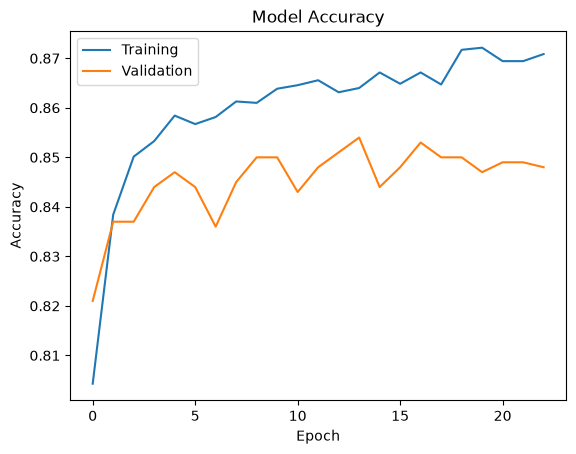

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])

plt.show()

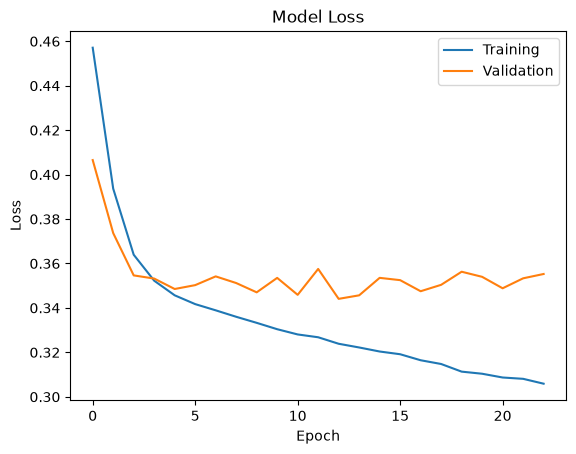

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])

plt.show()

In [33]:
## Load tensorboard Extension
%load_ext tensorboard

In [34]:
%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6006 (pid 30161), started 0:42:09 ago. (Use '!kill 30161' to kill it.)

In [35]:
## Load pickle files
